<a href="https://colab.research.google.com/github/likithams09/Generative-AI-Lab/blob/main/Exp_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Develop an auto encoder model to reconstruct MNIST dataset

1. Importing necessary libraries:

In [2]:
import tensorflow as tf
from tensorflow.keras import layers,Model
import matplotlib.pyplot as plt

2. Data Acquistion


In [3]:
(x_train,_),(x_test,_) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


3. Normalization


In [4]:
x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0


4. Flattening

In [5]:
x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)

5. Encoder Model


In [6]:
input_img = layers.Input(shape=(784,))
encoded = layers.Dense(128,activation='relu')(input_img)
encoded = layers.Dense(32,activation='relu')(encoded)

6. Decoder

In [7]:
decoded = layers.Dense(128,activation='relu')(encoded)
decoded = layers.Dense(784,activation='sigmoid')(decoded)

7. Create Autoencoder


In [8]:
autoencoder = Model(input_img,decoded)

8. Compile

In [9]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

9. Train


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0856 - val_loss: 0.0849
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0855 - val_loss: 0.0848
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0853 - val_loss: 0.0846
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0853 - val_loss: 0.0847
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0852 - val_loss: 0.0846
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0850 - val_loss: 0.0846
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0849 - val_loss: 0.0842
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0848 - val_loss: 0.0843
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0848 - val_loss: 0.0842
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0846 - val_loss: 0.0841
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


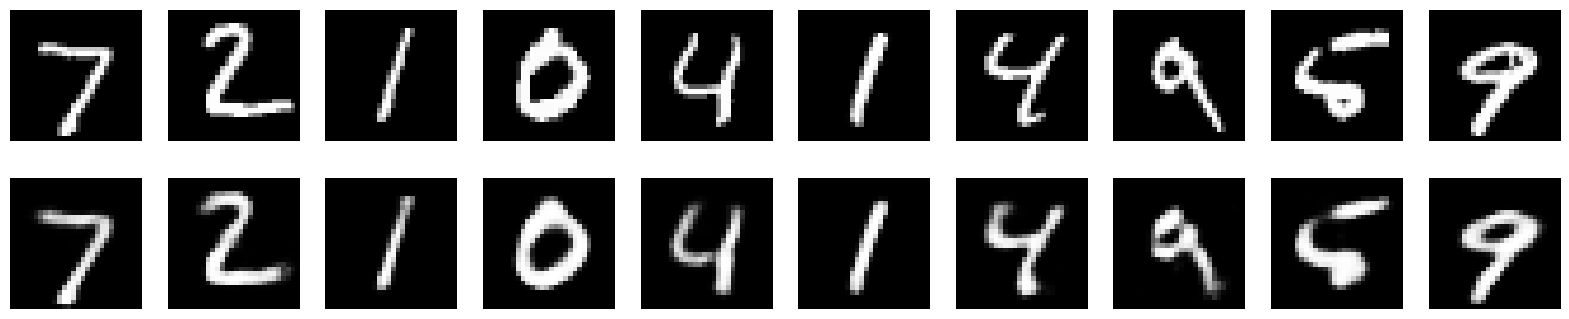

In [12]:
autoencoder.fit(
    x_train,
    x_train,
    epochs=10,
    batch_size=256,
    validation_data=(x_test, x_test)
)

# Reconstruct test images
reconstructed = autoencoder.predict(x_test)

# -------------------------
# Display original vs reconstructed
# -------------------------

n = 10

plt.figure(figsize=(20, 4))

for i in range(n):

    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()